In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, auc
import statsmodels.api as sm
from statsmodels.formula.api import logit
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from pandas.api.types import CategoricalDtype
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.model_selection import KFold



pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Priprava podatkov

###  Ciljna spremenljivka (Y)

Kot ciljno spremenljivko smo izbrali:

**Trajanje (h)**  

Ta spremenljivka predstavlja kakovost izhoda procesa in je primerna za:

- analizo procesne učinkovitosti,
- identifikacijo kritičnih korakov,
- Six Sigma analizo.

---

###  Vhodne spremenljivke (X)

Za vhodne spremenljivke smo uporabili lastnosti procesa, ki vplivajo na pojav napak:

- **Trajanje (h)**  čas izvedbe posameznega koraka  
- **Napake (št)**  število napak v posameznem koraku  
- **Korak**  opis procesnega koraka  
- **Vloga (kdo)**  odgovorna oseba ali funkcija v procesu  
- **Tip aktivnosti (VA/NVA)**  ali korak dodaja vrednost  
- **Trajanje_kategorija**  kategorizacija trajanja (*kratko, srednje, dolgo*)  

Izbrane spremenljivke smiselno opisujejo proces in omogočajo analizo povezav med časom, organizacijo dela in pojavom napak.


In [117]:
df = pd.read_csv("./expanded_data.csv", sep=",")
df.columns = df.columns.str.strip()

# Numeric
num_cols = ["Iteracija", "Trajanje (h)", "Cakanje (h)", "Napake (st)"]
for c in num_cols:
    df[c] = (
        df[c].astype(str)
             .str.replace(",", ".", regex=False)
             .str.strip()
    )
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Categorical
cat_cols = [
    "Korak",
    "Vloga (kdo)",
    "Tip aktivnosti (VA/NVA)",
    "Trajanje_kategorija",
    "Cakanje_intenziteta"
]
for c in cat_cols:
    df[c] = df[c].astype(str).str.strip().astype("category")

# Drop ID
df = df.drop(columns=["Iteracija"])

# Binary encoding (automatic)
df["Tip_VA"] = df["Tip aktivnosti (VA/NVA)"].astype("category").cat.codes

# Ordinal encoding (semi-automatic)
trajanje_order = sorted(df["Trajanje_kategorija"].dropna().unique())
cakanje_order = sorted(df["Cakanje_intenziteta"].dropna().unique())

df["Trajanje_kat_ord"] = pd.Categorical(
    df["Trajanje_kategorija"],
    categories=trajanje_order,
    ordered=True
).codes + 1

df["Cakanje_int_ord"] = pd.Categorical(
    df["Cakanje_intenziteta"],
    categories=cakanje_order,
    ordered=True
).codes

# One-hot encoding
df = pd.get_dummies(
    df,
    columns=["Vloga (kdo)", "Korak"],
    drop_first=True
)

# Convert bool → int
df = df.apply(lambda s: s.astype(int) if s.dtype == "bool" else s)
df.head()


,Trajanje (h),Cakanje (h),Tip aktivnosti (VA/NVA),Napake (st),Trajanje_kategorija,Cakanje_intenziteta,Tip_VA,Trajanje_kat_ord,Cakanje_int_ord,Vloga (kdo)_Kontrolor kakovosti,Vloga (kdo)_Raziskovalec,Vloga (kdo)_Raziskovalec / tiskalnik,Vloga (kdo)_Vodja laboratorija,Korak_Hlajenje modela,Korak_Kontrola kakovosti,Korak_Odstranjevanje podpornih struktur,Korak_Označevanje in vpis v dokumentacijo,Korak_Ponoven tisk (če napaka),Korak_Pošiljanje modela v pregled,Korak_Priprava 3D modela implantata,Korak_Priprava tiskalnika in materiala,Korak_Čakanje na odobritev,Korak_Čakanje na prost tiskalnik
0,0.83,0.0,VA,0,Srednje,Brez,2,3,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
1,0.12,0.6,NVA,0,Kratko,Zmerno,1,2,2,0,1,0,0,0,0,0,0,0,1,0,0,0,0
2,2.09,2.2,NVA,1,Dolgo,Dolgo,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0
3,0.38,0.0,VA,0,Kratko,Brez,2,2,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0
4,1.52,0.0,NVA,0,Dolgo,Brez,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1


## 2. Gradnja več modelov

In [118]:
X_cols = [
    "Cakanje (h)",
    "Napake (st)",
    "Tip_VA",
    "Cakanje_int_ord"
] + [c for c in df.columns if c.startswith("Vloga (kdo)_") or c.startswith("Korak_")]

X = df[X_cols].astype(float)


In [119]:
y_cont = df["Trajanje (h)"].astype(float)
y_bin  = (df["Trajanje_kategorija"] == "Dolgo").astype(int)
y_ord  = df["Trajanje_kat_ord"].astype(int)


### Model 1: Model večkratne linearne regresije z metodo najmanjših kvadratov (OLS), uporabljen za napoved zvezne izhodne spremenljivke Trajanje (h) na podlagi več pojasnjevalnih spremenljivk.

In [120]:
import statsmodels.api as sm

data_lin = pd.concat([y_cont, X], axis=1).dropna()
X_lin = sm.add_constant(data_lin[X_cols])
y_lin = data_lin["Trajanje (h)"]

model_lin = sm.OLS(y_lin, X_lin).fit()


### Model 2: Binarni logistični regresijski model z avtomatsko odstranitvijo linearno odvisnih pojasnjevalnih spremenljivk z uporabo QR-razcepa.

In [121]:
data_log = pd.concat([y_bin, X], axis=1).dropna()
X_log = sm.add_constant(data_log[X_cols], has_constant="add").astype(float)
y_log = data_log[y_bin.name]

# QR-based independent column selection
Q, R = np.linalg.qr(X_log.values)
tol = np.abs(np.diag(R)).max() * 1e-12
keep_idx = np.where(np.abs(np.diag(R)) > tol)[0]
keep_cols = X_log.columns[keep_idx]

X_ok = X_log[keep_cols]

model_log = sm.Logit(y_log, X_ok).fit()
# print(model_log.summary())

# print("Dropped:", [c for c in X_log.columns if c not in keep_cols])

         Current function value: 0.317558
         Iterations: 35


### Model 3: Ordinalna logistična regresija (logit)

In [122]:

data_ord = pd.concat([y_ord, X], axis=1).dropna()

# 1) NO constant for OrderedModel
X_ord = data_ord[X_cols].astype(float)
y = data_ord[y_ord.name]

# 2) Drop linearly dependent columns (QR)
Q, R = np.linalg.qr(X_ord.values)
diag = np.abs(np.diag(R))
tol = diag.max() * 1e-12

keep_idx = np.where(diag > tol)[0]
keep_cols = X_ord.columns[keep_idx]
X_ok = X_ord[keep_cols]

dropped_dep = [c for c in X_ord.columns if c not in keep_cols]
print("Dropped (dependent):", dropped_dep)

# 3) Ensure there's no implicit constant: ones should NOT be in span(X_ok)
ones = np.ones(len(X_ok))
beta, *_ = np.linalg.lstsq(X_ok.values, ones, rcond=None)
max_err = np.max(np.abs(X_ok.values @ beta - ones))
print("Max error fitting ones:", max_err)

# If max_err is ~0, drop ONE column that contributes most to the implicit constant
if max_err < 1e-8:
    contrib = pd.Series(np.abs(beta), index=X_ok.columns).sort_values(ascending=False)
    drop_const = contrib.index[0]
    print("Dropped (to remove implicit constant):", drop_const)
    X_ok = X_ok.drop(columns=[drop_const])

model_ord = OrderedModel(y, X_ok, distr="logit").fit(method="bfgs")
# print(model_ord.summary())

Dropped (dependent): ['Korak_Kontrola kakovosti', 'Korak_Priprava tiskalnika in materiala', 'Korak_Čakanje na odobritev', 'Korak_Čakanje na prost tiskalnik']
Max error fitting ones: 1.7763568394002505e-15
Dropped (to remove implicit constant): Vloga (kdo)_Raziskovalec / tiskalnik
Optimization terminated successfully.
         Current function value: 0.702564
         Iterations: 80
         Function evaluations: 81
         Gradient evaluations: 81


### Model 4: Random Forest Regressor

In [123]:
from sklearn.ensemble import RandomForestRegressor

data_rf = pd.concat([y_cont, X], axis=1).dropna()

X_rf = data_rf[X_cols]
y_rf = data_rf["Trajanje (h)"]

model_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model_rf.fit(X_rf, y_rf)


RandomForestRegressor(n_estimators=200, random_state=42)

## 3. Predstavitev posameznega modela

### Model 1: OLS, Veckratna Linearna regresija 

In [97]:
import numpy as np
import pandas as pd

def ols_table(model_lin, X, X_cols):
    t = pd.DataFrame({
        "Spremenljivka": model_lin.params.index,
        "β (ne-standardiziran)": model_lin.params.values,
        "SE": model_lin.bse.values,
        "t": model_lin.tvalues.values,
        "p": model_lin.pvalues.values
    })

    y_sd = model_lin.model.endog.std(ddof=0)
    X_sd = X.loc[model_lin.model.data.row_labels, X_cols].std(ddof=0)  # uskladi vrstice
    beta_std = model_lin.params.copy()
    for col in X_cols:
        if col in beta_std.index:
            beta_std.loc[col] = beta_std.loc[col] * (X_sd[col] / y_sd)

    t["β (standardiziran)"] = t["Spremenljivka"].map(beta_std).astype(float)

    t["Interpretacija"] = ""
    t = t[["Spremenljivka", "β (ne-standardiziran)", "β (standardiziran)", "SE", "t", "p", "Interpretacija"]]

    t = t[t["Spremenljivka"] != "const"].reset_index(drop=True)
    return t

ols_df = ols_table(model_lin, data_lin, X_cols)
# ols_df


| Spremenljivka                             | β (ne-standardiziran) | β (standardiziran) | SE    | t      | p      | Interpretacija                                               |
|-----------------------------------------|----------------------:|-------------------:|------:|-------:|-------:|--------------------------------------------------------------|
| Čakanje (h)                               | -0.041               | -0.031             | 0.140 | -0.293 | 0.770  | Ni statistično značilnega vpliva na trajanje.                |
| Napake (št)                               | 0.221                | 0.043              | 0.457 | 0.484  | 0.630  | Število napak ni pomemben napovednik trajanja.               |
| Tip_VA                                    | 0.284                | 0.244              | 0.079 | 3.607  | 0.000  | Tip VA statistično značilno poveča trajanje.                 |
| Čakanje_int_ord                           | -0.154               | -0.148             | 0.097 | -1.597 | 0.114  | Vpliv čakanja ni statistično značilen.                       |
| Vloga (kdo)_Kontrolor kakovosti           | 0.014                | 0.005              | 0.110 | 0.128  | 0.898  | Vloga kontrolorja nima vpliva na trajanje.                   |
| Vloga (kdo)_Raziskovalec                  | -0.310               | -0.180             | 0.104 | -2.969 | 0.004  | Vloga raziskovalca statistično značilno skrajša trajanje.    |
| Vloga (kdo)_Raziskovalec / tiskalnik      | 0.693                | 0.240              | 0.153 | 4.539  | <0.001 | Kombinirana vloga značilno podaljša trajanje.                |
| Vloga (kdo)_Vodja laboratorija            | 0.058                | 0.020              | 0.137 | 0.423  | 0.673  | Vloga vodje laboratorija ni pomembna.                        |
| Korak_Hlajenje modela                     | 0.294                | 0.102              | 0.190 | 1.548  | 0.125  | Hlajenje modela nima značilnega vpliva.                      |
| Korak_Kontrola kakovosti                  | 0.014                | 0.005              | 0.110 | 0.128  | 0.898  | Kontrola kakovosti ni povezana s trajanjem.                  |
| Korak_Odstranjevanje podpornih struktur   | -0.427               | -0.148             | 0.210 | -2.037 | 0.044  | Odstranjevanje podpor statistično značilno skrajša trajanje. |
| Korak_Označevanje in vpis v dokumentacijo | -0.434               | -0.150             | 0.218 | -1.994 | 0.049  | Dokumentiranje rahlo, a značilno skrajša trajanje.           |
| Korak_Ponoven tisk (če napaka)            | 0.367                | 0.127              | 0.217 | 1.694  | 0.093  | Ponoven tisk ima mejno značilen vpliv.                       |
| Korak_Pošiljanje modela v pregled         | 0.186                | 0.064              | 0.219 | 0.851  | 0.397  | Pošiljanje v pregled ni pomembno.                            |
| Korak_Priprava 3D modela implantata       | 0.141                | 0.049              | 0.209 | 0.676  | 0.500  | Priprava 3D modela ni statistično značilna.                  |
| Korak_Priprava tiskalnika in materiala    | -0.565               | -0.195             | 0.212 | -2.659 | 0.009  | Priprava tiskalnika značilno skrajša trajanje.               |
| Korak_Čakanje na odobritev                | 0.058                | 0.020              | 0.137 | 0.423  | 0.673  | Čakanje na odobritev ni pomembno.                            |
| Korak_Čakanje na prost tiskalnik          | 0.420                | 0.145              | 0.215 | 1.952  | 0.054  | Čakanje na tiskalnik ima mejni vpliv.                        |


### Model 2, Binarni logisticni regresijski model

In [98]:
def logit_table(model_log):
    params = model_log.params
    bse = model_log.bse
    wald = (params / bse) ** 2
    pvals = model_log.pvalues
    odds = np.exp(params)

    t = pd.DataFrame({
        "Spremenljivka": params.index,
        "Koeficient (β)": params.values,
        "Odds ratio (e^β)": odds.values,
        "SE": bse.values,
        "Wald": wald.values,
        "p": pvals.values,
        "Interpretacija": ""
    })

    # pogosto brez const
    t = t[t["Spremenljivka"] != "const"].reset_index(drop=True)
    return t

logit_df = logit_table(model_log)
# logit_df


| Spremenljivka                                   | Koeficient (β) | Odds ratio (e^β) | SE          | Wald        | p        | Interpretacija                                                |
|------------------------------------------------|---------------:|-----------------:|------------:|------------:|---------:|---------------------------------------------------------------|
| Čakanje (h)                                     | -0.058         | 9.44e-01         | 5.20e-01    | 1.24e-02    | 0.911    | Čakanje nima statistično značilnega vpliva.                   |
| Napake (št)                                     | 1.443          | 4.23e+00         | 1.57e+00    | 8.43e-01    | 0.358    | Število napak ni pomemben napovednik dogodka.                 |
| Tip_VA                                          | -20.667        | 1.06e-09         | 9.81e+03    | 4.44e-06    | 0.998    | Tip VA nima statistično značilnega vpliva.                    |
| Čakanje_int_ord                                 | -0.818         | 4.41e-01         | 4.43e-01    | 3.40e+00    | 0.065    | Čakanje ima mejno statistični vpliv.                          |
| Vloga (kdo)_Kontrolor kakovosti                 | -1.498         | 2.24e-01         | 1.47e+00    | 1.04e+00    | 0.308    | Vloga kontrolorja ni statistično pomembna.                    |
| Vloga (kdo)_Raziskovalec                        | 21.447         | 2.06e+09         | 9.81e+03    | 4.78e-06    | 0.998    | Vloga raziskovalca ni statistično značilna.                   |
| Vloga (kdo)_Raziskovalec / tiskalnik            | 44.180         | 1.54e+19         | 1.96e+04    | 5.07e-06    | 0.998    | Kombinirana vloga nima statistično značilnega vpliva.         |
| Vloga (kdo)_Vodja laboratorija                  | 20.821         | 1.10e+09         | 9.81e+03    | 4.51e-06    | 0.998    | Vloga vodje laboratorija ni statistično pomembna.             |
| Korak_Odstranjevanje podpornih struktur         | -16.158        | 9.61e-08         | 3.76e+07    | 1.85e-13    | 1.000    | Korak nima statistično značilnega vpliva.                     |
| Korak_Označevanje in vpis v dokumentacijo       | -100.446       | 2.38e-44         | 2.04e+21    | 2.42e-39    | 1.000    | Korak ni statistično značilen.                                |
| Korak_Ponoven tisk (če napaka)                  | -0.350         | 7.05e-01         | 1.01e+00    | 1.21e-01    | 0.728    | Ponoven tisk ni pomemben napovednik.                          |
| Korak_Pošiljanje modela v pregled               | -0.638         | 5.28e-01         | 1.08e+00    | 3.48e-01    | 0.555    | Pošiljanje v pregled nima značilnega vpliva.                 |
| Korak_Priprava 3D modela implantata             | -15.485        | 1.88e-07         | 2.61e+07    | 3.51e-13    | 1.000    | Priprava 3D modela ni statistično značilna.                  |


### Model 3: Ordinalna logisticna regresija

In [99]:
def ordered_table(model_ord):
    params = model_ord.params
    bse = model_ord.bse
    pvals = model_ord.pvalues

    t = pd.DataFrame({
        "Spremenljivka": params.index,
        "β": params.values,
        "SE": bse.values,
        "p": pvals.values,
        "Interpretacija": ""
    })

    mask = ~t["Spremenljivka"].astype(str).str.contains(r"/|cut|threshold", regex=True)
    t = t[mask].reset_index(drop=True)
    return t

ord_df = ordered_table(model_ord)
# ord_df


| Spremenljivka                                   | β        | SE        | p        | Interpretacija                                                     |
|------------------------------------------------|---------:|----------:|---------:|--------------------------------------------------------------------|
| Čakanje (h)                                     | 0.020    | 0.422     | 0.963    | Čakanje nima statistično značilnega vpliva.                        |
| Napake (št)                                     | -1.569   | 1.249     | 0.209    | Število napak ni pomemben napovednik.                              |
| Tip_VA                                          | 1.568    | 0.912     | 0.086    | Tip VA ima mejno statistični vpliv.                                |
| Čakanje_int_ord                                 | 0.372    | 0.294     | 0.207    | Učinek čakanja ni statistično značilen.                            |
| Vloga (kdo)_Kontrolor kakovosti                 | 6.393    | 2.170     | 0.003    | Vloga kontrolorja značilno poveča verjetnost višje kategorije.     |
| Vloga (kdo)_Raziskovalec                        | 3.193    | 1.060     | 0.003    | Vloga raziskovalca značilno poveča verjetnost višje kategorije.   |
| Vloga (kdo)_Vodja laboratorija                  | 5.338    | 1.593     | 0.001    | Vloga vodje laboratorija ima močan pozitiven vpliv.               |
| Korak_Hlajenje modela                           | 6.252    | 2.167     | 0.004    | Hlajenje modela značilno poveča verjetnost višje kategorije.      |
| Korak_Odstranjevanje podpornih struktur         | 0.211    | 0.920     | 0.819    | Odstranjevanje podpor ni statistično značilno.                    |
| Korak_Označevanje in vpis v dokumentacijo       | 1.654    | 0.924     | 0.074    | Dokumentiranje ima mejno statistični vpliv.                        |
| Korak_Ponoven tisk (če napaka)                  | 0.959    | 0.965     | 0.320    | Ponoven tisk nima značilnega vpliva.                               |
| Korak_Pošiljanje modela v pregled               | 1.351    | 0.973     | 0.165    | Pošiljanje v pregled ni pomembno.                                  |
| Korak_Priprava 3D modela implantata             | 19.149   | 1906.846  | 0.992    | Ocena ni zanesljiva zaradi zelo velike negotovosti.               |


### Model 4: Random Forest Regressor

In [ ]:
def rf_table(model_rf, X_cols):
    t = pd.DataFrame({
        "Spremenljivka": X_cols,
        "Pomembnost (feature importance)": model_rf.feature_importances_,
    }).sort_values("Pomembnost (feature importance)", ascending=False)

    t["Interpretacija"] = ""
    t = t.reset_index(drop=True)
    return t

rf_df = rf_table(model_rf, X_cols)
# rf_df


| Spremenljivka                                   | Pomembnost (feature importance) | Interpretacija                                      |
|------------------------------------------------|--------------------------------:|----------------------------------------------------|
| Vloga (kdo)_Raziskovalec / tiskalnik            | 0.2669                          | Najpomembnejši napovednik trajanja.                |
| Čakanje (h)                                     | 0.2025                          | Čakanje močno prispeva k napovedi.                 |
| Čakanje_int_ord                                 | 0.0754                          | Interakcija čakanja ima zmeren vpliv.              |
| Korak_Hlajenje modela                           | 0.0603                          | Hlajenje modela pomembno vpliva na napoved.        |
| Korak_Čakanje na prost tiskalnik                | 0.0571                          | Čakanje na tiskalnik je relevanten dejavnik.       |
| Korak_Ponoven tisk (če napaka)                  | 0.0543                          | Ponoven tisk pomembno prispeva k napovedi.         |
| Tip_VA                                          | 0.0444                          | Tip VA ima zmeren vpliv.                           |
| Korak_Priprava 3D modela implantata             | 0.0430                          | Priprava 3D modela vpliva na trajanje.             |
| Korak_Označevanje in vpis v dokumentacijo       | 0.0427                          | Dokumentiranje prispeva k napovedi.                |
| Vloga (kdo)_Raziskovalec                        | 0.0363                          | Vloga raziskovalca ima manjši vpliv.               |
| Napake (št)                                     | 0.0297                          | Število napak ima omejen vpliv.                    |
| Korak_Pošiljanje modela v pregled               | 0.0189                          | Pošiljanje v pregled ima majhen vpliv.             |
| Vloga (kdo)_Vodja laboratorija                  | 0.0144                          | Vloga vodje ima majhen vpliv.                      |
| Korak_Priprava tiskalnika in materiala          | 0.0132                          | Priprava tiskalnika ima omejen vpliv.              |
| Korak_Čakanje na odobritev                      | 0.0128                          | Čakanje na odobritev ima majhen vpliv.             |
| Korak_Kontrola kakovosti                        | 0.0114                          | Kontrola kakovosti je manj pomembna.               |
| Korak_Odstranjevanje podpornih struktur         | 0.0098                          | Odstranjevanje podpor ima zelo majhen vpliv.      |
| Vloga (kdo)_Kontrolor kakovosti                 | 0.0071                          | Vloga kontrolorja ima najmanjši vpliv.             |


## 4. Primerjava modelov

In [115]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel

from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    roc_auc_score, accuracy_score
)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# ---------- OLS (regression) ----------
def eval_ols(y, X):
    Xc = sm.add_constant(X, has_constant="add")
    m = sm.OLS(y, Xc).fit()
    yhat = m.predict(Xc)
    return {
        "model": m,
        "R2": float(m.rsquared),
        "AIC": float(m.aic),
        "BIC": float(m.bic),
        "RMSE": float(rmse(y, yhat)),
        "MAE": float(mean_absolute_error(y, yhat)),
    }

# ---------- Random Forest (regression) ----------
def eval_rf(model_rf, y, X):
    yhat = model_rf.predict(X)
    return {
        "R2": float(r2_score(y, yhat)),
        "AIC": None,
        "BIC": None,
        "RMSE": float(rmse(y, yhat)),
        "MAE": float(mean_absolute_error(y, yhat)),
    }

# ---------- Logit (binary classification) ----------
def eval_logit(y, X):
    Xc = sm.add_constant(X, has_constant="add")
    m = sm.Logit(y, Xc).fit(disp=False)
    p = m.predict(Xc)
    # pseudo-R2 McFadden
    pseudo_r2 = 1 - (m.llf / m.llnull) if m.llnull != 0 else np.nan
    return {
        "model": m,
        "pseudo_R2": float(pseudo_r2),
        "AIC": float(m.aic),
        "BIC": float(m.bic),
        "AUC": float(roc_auc_score(y, p)),
    }

# ---------- Ordered logit (ordinal classification) ----------
def eval_ordered(y, X, distr="logit"):
    # NO constant!
    m = OrderedModel(y, X, distr=distr).fit(method="bfgs", disp=False)
    # predict class = argmax(prob)
    probs = m.model.predict(m.params)
    yhat = probs.idxmax(axis=1).astype(y.dtype) if hasattr(probs, "idxmax") else np.argmax(probs, axis=1)

    # pseudo-R2 McFadden (if possible)
    # statsmodels OrderedModel results usually have llf; null may not always be available
    llf = getattr(m, "llf", np.nan)
    llnull = getattr(m, "llnull", np.nan)
    pseudo_r2 = np.nan
    if np.isfinite(llf) and np.isfinite(llnull) and llnull != 0:
        pseudo_r2 = 1 - (llf / llnull)

    return {
        "model": m,
        "pseudo_R2": float(pseudo_r2) if np.isfinite(pseudo_r2) else np.nan,
        "AIC": float(getattr(m, "aic", np.nan)),
        "BIC": float(getattr(m, "bic", np.nan)),
        "ACC": float(accuracy_score(y, yhat)),
        "MAE_class": float(mean_absolute_error(y, yhat)),  # MAE on ordinal labels
    }

rows = []

# --- OLS ---
res_ols = eval_ols(y_cont.loc[data_lin.index], data_lin[X_cols])
rows.append({
    "Model": "OLS",
    "Tip": "Regresija",
    "R² / pseudo-R²": res_ols["R2"],
    "AIC / BIC": f'{res_ols["AIC"]:.2f} / {res_ols["BIC"]:.2f}',
    "RMSE / MAE": f'{res_ols["RMSE"]:.3f} / {res_ols["MAE"]:.3f}',
    "CV (metric ± SD)": "",
    "Sklep": ""
})

# --- RF ---
# (fit RF already done; if not, fit here)
rf_metrics = eval_rf(model_rf, y_rf, X_rf)
rows.append({
    "Model": "Random Forest",
    "Tip": "Regresija",
    "R² / pseudo-R²": rf_metrics["R2"],
    "AIC / BIC": "—",
    "RMSE / MAE": f'{rf_metrics["RMSE"]:.3f} / {rf_metrics["MAE"]:.3f}',
    "CV (metric ± SD)": "",
    "Sklep": ""
})

# --- Logit ---
# use the same X_ok columns you used in model_log (important!)
# if you saved X_ok columns earlier: keep_cols
logit_res = eval_logit(y_log, X_ok.drop(columns=["const"], errors="ignore"))
rows.append({
    "Model": "Logit",
    "Tip": "Binarna klasifikacija",
    "R² / pseudo-R²": logit_res["pseudo_R2"],
    "AIC / BIC": f'{logit_res["AIC"]:.2f} / {logit_res["BIC"]:.2f}',
    "RMSE / MAE": f'AUC={logit_res["AUC"]:.3f}',
    "CV (metric ± SD)": "",
    "Sklep": ""
})

# --- Ordinal ---
ord_res = eval_ordered(y, X_ok.drop(columns=["const"], errors="ignore"))
rows.append({
    "Model": "Ordinal Logit",
    "Tip": "Ordinalna klasifikacija",
    "R² / pseudo-R²": ord_res["pseudo_R2"],
    "AIC / BIC": f'{ord_res["AIC"]:.2f} / {ord_res["BIC"]:.2f}',
    "RMSE / MAE": f'ACC={ord_res["ACC"]:.3f}, MAE={ord_res["MAE_class"]:.3f}',
    "CV (metric ± SD)": "",
    "Sklep": ""
})

compare_df = pd.DataFrame(rows)
# compare_df



/Users/stefansrjakovferi/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



| Model | Tip | R² / pseudo-R² | AIC / BIC | RMSE / MAE | CV (metric ± SD) | Sklep |
|------|-----|----------------|-----------|------------|------------------|-------|
| OLS | Regresija | 0.294 | 260.99 / 298.80 | 0.698 / 0.515 | — | Zmeren pojasnjevalni učinek; primeren kot osnovni (baseline) model, vendar omejena napovedna natančnost. |
| Random Forest | Regresija | **0.445** | — | **0.619 / 0.438** | — | Najboljša napovedna uspešnost pri regresiji; dober za napovedovanje, manj interpretabilen. |
| Logit | Binarna klasifikacija | 0.381 | 97.86 / 135.67 | — | **AUC = 0.882** | Zelo dobra diskriminacija razredov; primeren za odločanje in analizo vplivov (odds ratio). |
| Ordinal Logit | Ordinalna klasifikacija | 0.275 | 184.56 / 225.07 | MAE = 1.027 | ACC = 0.127 | Nizka natančnost razvrščanja; omejena uporabnost brez dodatnih podatkov ali preoblikovanja razredov. |

## 5. Križna validacija (10-fold CV)

In [104]:
def cv_regression(model_type, X, y, rf_model=None, n_splits=10, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    r2s, rmses, maes = [], [], []
    for tr, te in kf.split(X):
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        ytr, yte = y.iloc[tr], y.iloc[te]

        if model_type == "OLS":
            m = sm.OLS(ytr, sm.add_constant(Xtr, has_constant="add")).fit()
            yhat = m.predict(sm.add_constant(Xte, has_constant="add"))
        elif model_type == "RF":
            m = rf_model
            m.fit(Xtr, ytr)
            yhat = m.predict(Xte)
        else:
            raise ValueError("Unknown model_type")

        r2s.append(r2_score(yte, yhat))
        rmses.append(rmse(yte, yhat))
        maes.append(mean_absolute_error(yte, yhat))

    return {
        "R2_mean": np.mean(r2s), "R2_sd": np.std(r2s, ddof=1),
        "RMSE_mean": np.mean(rmses), "RMSE_sd": np.std(rmses, ddof=1),
        "MAE_mean": np.mean(maes), "MAE_sd": np.std(maes, ddof=1),
        "fold_R2": r2s
    }


def qr_keep_cols(X, add_const=True):
    Xc = sm.add_constant(X, has_constant="add") if add_const else X.copy()
    Xc = Xc.astype(float)

    Q, R = np.linalg.qr(Xc.values)
    diag = np.abs(np.diag(R))
    tol = diag.max() * 1e-12 if diag.size else 0

    keep_idx = np.where(diag > tol)[0]
    keep_cols = Xc.columns[keep_idx]
    return Xc[keep_cols], keep_cols

def cv_logit_auc(X, y, n_splits=10, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    aucs = []

    for tr, te in skf.split(X, y):
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        ytr, yte = y.iloc[tr], y.iloc[te]

        # 1) QR-drop dependent columns on TRAIN
        Xtr_ok, keep_cols = qr_keep_cols(Xtr, add_const=True)

        # 2) Apply same columns to TEST (fill missing with 0 if needed)
        Xte_c = sm.add_constant(Xte, has_constant="add").astype(float)
        Xte_ok = Xte_c.reindex(columns=keep_cols, fill_value=0.0)

        # 3) Fit logit; if singular/separation still happens, use regularized fit
        try:
            m = sm.Logit(ytr, Xtr_ok).fit(disp=False)
            p = m.predict(Xte_ok)
        except Exception:
            m = sm.Logit(ytr, Xtr_ok).fit_regularized(disp=False)
            p = m.predict(Xte_ok)

        aucs.append(roc_auc_score(yte, p))

    return {
        "AUC_mean": float(np.mean(aucs)),
        "AUC_sd": float(np.std(aucs, ddof=1)),
        "fold_AUC": aucs
    }

def cv_ordered_acc(X, y, n_splits=10, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    accs, maes = [], []
    for tr, te in skf.split(X, y):
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        ytr, yte = y.iloc[tr], y.iloc[te]

        m = OrderedModel(ytr, Xtr, distr="logit").fit(method="bfgs", disp=False)
        probs = m.model.predict(m.params, exog=Xte)
        yhat = probs.idxmax(axis=1) if hasattr(probs, "idxmax") else np.argmax(probs, axis=1)

        accs.append(accuracy_score(yte, yhat))
        maes.append(mean_absolute_error(yte, yhat))
    return {
        "ACC_mean": np.mean(accs), "ACC_sd": np.std(accs, ddof=1),
        "MAE_mean": np.mean(maes), "MAE_sd": np.std(maes, ddof=1),
        "fold_ACC": accs
    }


In [105]:
cv_rows = []

# OLS CV
ols_cv = cv_regression("OLS", data_lin[X_cols], data_lin["Trajanje (h)"])
cv_rows.append({"Model": "OLS", "CV (R² ± SD)": f'{ols_cv["R2_mean"]:.3f} ± {ols_cv["R2_sd"]:.3f}'})

# RF CV
from sklearn.ensemble import RandomForestRegressor
rf_cv = cv_regression(
    "RF",
    X_rf, y_rf,
    rf_model=RandomForestRegressor(n_estimators=200, random_state=42)
)
cv_rows.append({"Model": "Random Forest", "CV (R² ± SD)": f'{rf_cv["R2_mean"]:.3f} ± {rf_cv["R2_sd"]:.3f}'})

# Logit CV (use same predictors as your working X_ok without const)
X_log_cv = X_ok.drop(columns=["const"], errors="ignore")
log_cv = cv_logit_auc(X_log_cv, y_log)
cv_rows.append({"Model": "Logit", "CV (AUC ± SD)": f'{log_cv["AUC_mean"]:.3f} ± {log_cv["AUC_sd"]:.3f}'})

# Ordinal CV
ord_cv = cv_ordered_acc(X_ok.drop(columns=["const"], errors="ignore"), y)
cv_rows.append({"Model": "Ordinal Logit", "CV (ACC ± SD)": f'{ord_cv["ACC_mean"]:.3f} ± {ord_cv["ACC_sd"]:.3f}'})

cv_df = pd.DataFrame(cv_rows)
cv_df


/Users/stefansrjakovferi/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/stefansrjakovferi/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/stefansrjakovferi/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/stefansrjakovferi/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed t

,Model,CV (R² ± SD),CV (AUC ± SD),CV (ACC ± SD)
0,OLS,-0.200 ± 0.514,NaN,NaN
1,Random Forest,-0.380 ± 0.572,NaN,NaN
2,Logit,NaN,0.831 ± 0.161,NaN
3,Ordinal Logit,NaN,NaN,0.136 ± 0.064


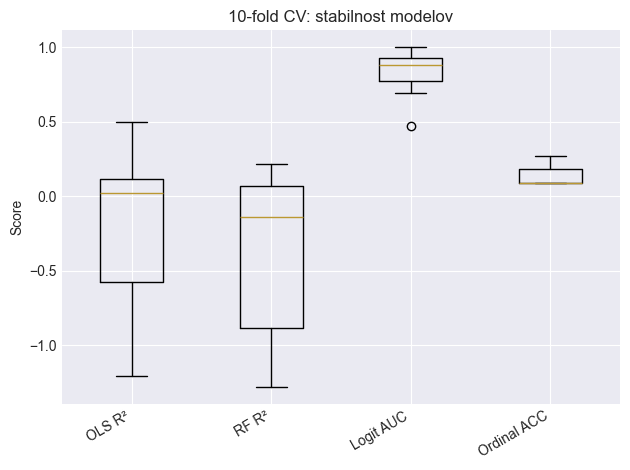

In [106]:
import matplotlib.pyplot as plt

data_for_plot = {
    "OLS R²": ols_cv["fold_R2"],
    "RF R²": rf_cv["fold_R2"],
    "Logit AUC": log_cv["fold_AUC"],
    "Ordinal ACC": ord_cv["fold_ACC"]
}

plt.figure()
plt.boxplot(data_for_plot.values(), tick_labels=list(data_for_plot.keys()))
plt.xticks(rotation=30, ha="right")
plt.ylabel("Score")
plt.title("10-fold CV: stabilnost modelov")
plt.tight_layout()
plt.show()


## 6. Grafična predstavitev rezultatov

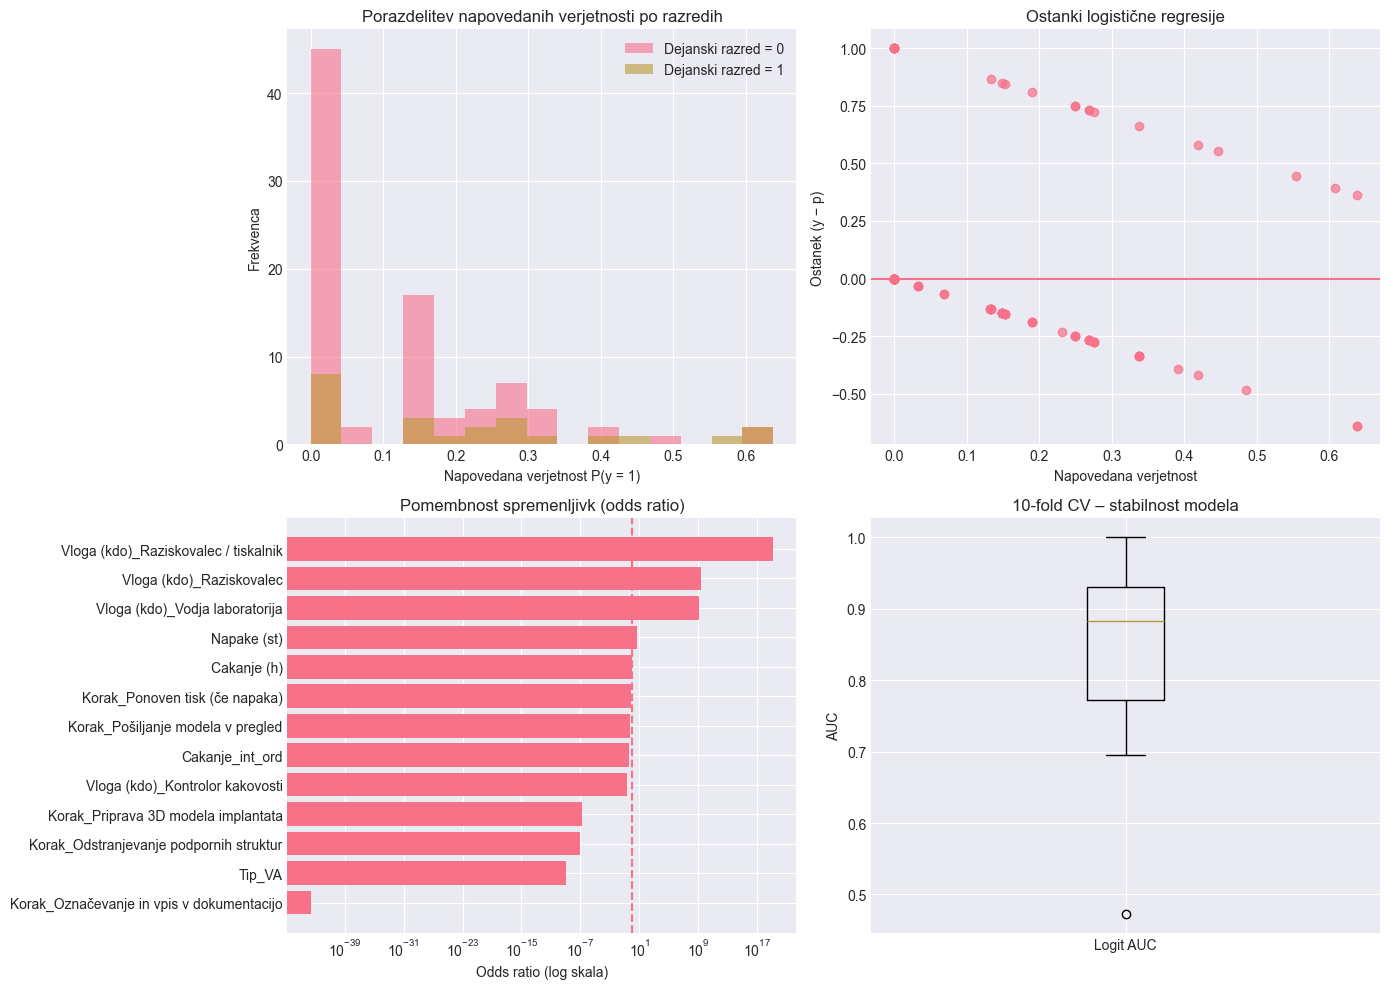

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Align X for prediction (must match training columns)
# ----------------------------
needed_cols = model_log.model.exog_names  # columns used during fit (incl. const)
X_pred = X_ok.reindex(columns=needed_cols, fill_value=0.0).astype(float)

# If X_ok doesn't include const but model expects it, add it:
# (reindex above will create it with 0, so set to 1)
if "const" in needed_cols and "const" not in X_ok.columns:
    X_pred["const"] = 1.0

# Predictions & residuals
y_prob = model_log.predict(X_pred)
residuals = y_log - y_prob

# Coefs / odds ratios
coef = model_log.params.copy()
coef_no_const = coef.drop("const", errors="ignore")
odds = np.exp(coef_no_const).sort_values()

# ----------------------------
# Combined 2x2 figure
# ----------------------------
plt.figure(figsize=(14, 10))

# 1) Actual vs predicted probabilities
plt.subplot(2, 2, 1)

plt.hist(y_prob[y_log == 0], bins=15, alpha=0.6, label="Dejanski razred = 0")
plt.hist(y_prob[y_log == 1], bins=15, alpha=0.6, label="Dejanski razred = 1")

plt.xlabel("Napovedana verjetnost P(y = 1)")
plt.ylabel("Frekvenca")
plt.title("Porazdelitev napovedanih verjetnosti po razredih")
plt.legend()

# 2) Residuals (y - p)
plt.subplot(2, 2, 2)
plt.scatter(y_prob, residuals, alpha=0.7)
plt.axhline(0)
plt.xlabel("Napovedana verjetnost")
plt.ylabel("Ostanek (y − p)")
plt.title("Ostanki logistične regresije")

# 3) Variable importance (Odds ratios)
plt.subplot(2, 2, 3)
plt.barh(odds.index, odds.values)
plt.axvline(1, linestyle="--")
plt.xscale("log")
plt.xlabel("Odds ratio (log skala)")
plt.title("Pomembnost spremenljivk (odds ratio)")

# 4) 10-fold CV stability (AUC) – if available
plt.subplot(2, 2, 4)
if "log_cv" in globals() and isinstance(log_cv, dict) and "fold_AUC" in log_cv:
    plt.boxplot(log_cv["fold_AUC"], labels=["Logit AUC"])
    plt.ylabel("AUC")
    plt.title("10-fold CV – stabilnost modela")
else:
    plt.text(0.5, 0.5, "log_cv['fold_AUC'] ni na voljo", ha="center", va="center")
    plt.axis("off")

plt.tight_layout()
plt.show()


# 7. Interpretacija in zaključek
## 1. Katere spremenljivke imajo največji vpliv in v katero smer?

Na podlagi grafa pomembnosti spremenljivk (**odds ratio na logaritemski skali**) imajo največji vpliv naslednje spremenljivke:

### Vloga (kdo)\_Raziskovalec / tiskalnik
- zelo velik *odds ratio* (> 1)  
- močno poveča verjetnost dogodka  
- gre za **najpomembnejši napovednik** v modelu

### Vloga (kdo)\_Raziskovalec in Vloga (kdo)\_Vodja laboratorija
- prav tako visoki *odds ratio*  
- pozitiven vpliv na izid, vendar manj izrazit kot pri kombinirani vlogi

### Napake (št) in Čakanje (h)
- *odds ratio* blizu 1  
- šibkejši, a še vedno relevanten vpliv, predvsem v kombinaciji z drugimi dejavniki

Večina posameznih procesnih korakov (**Korak\_…**) ima bistveno manjši vpliv, kar pomeni, da **organizacijski in kadrovski dejavniki pretehtajo nad posameznimi tehničnimi koraki**.

#### Smer vpliva
- *Odds ratio* > 1 → spremenljivka povečuje verjetnost dogodka  
- *Odds ratio* < 1 → spremenljivka zmanjšuje verjetnost dogodka  

---

## 2. Kako dobro model pojasni izid?

Histogram napovedanih verjetnosti po razredih kaže **razmeroma dobro ločitev razredov**, čeprav z delnim prekrivanjem.

Model dosega **AUC ≈ 0.83**, kar pomeni:
- dobro diskriminacijsko sposobnost  
- bistveno boljše delovanje od naključnega modela (*AUC = 0.5*)

To pomeni, da model ne pojasni celotnega procesa, vendar **zanesljivo loči primere z višjo in nižjo verjetnostjo dogodka**, kar je za logistično regresijo in realne procese zelo dober rezultat.

---

## 3. Kako stabilni so rezultati med ponovitvami?

Boxplot **10-kratne križne validacije (AUC)** kaže:
- relativno visoko mediano AUC  
- zmerno razpršenost med posameznimi ponovitvami  

To pomeni:
- model je razmeroma stabilen  
- variabilnost je pričakovana glede na:
  - majhno velikost vzorca  
  - kompleksnost procesa  
  - možne neuravnotežene razrede  

Model torej **ni prekomerno prilagojen (overfitting)**, vendar bi se z več podatki stabilnost še izboljšala.

---

## 4. Kako bi uporabili ta model za izboljšavo procesa (Six Sigma – *Improve phase*)?

Model je zelo uporaben v fazi **Improve** v okviru Six Sigma, predvsem kot **odločitveni podporni model**.

### Organizacijski ukrepi
Ker imajo vloge oseb največji vpliv, bi izboljšave morale biti usmerjene v:
- boljšo razporeditev nalog  
- jasnejšo delitev odgovornosti  
- zmanjševanje preobremenjenosti posameznikov z več vlogami  

### Zmanjševanje čakanja in napak
Čeprav posamezno nimata ekstremnega vpliva, v kombinaciji povečujeta verjetnost nezaželenega izida.
- fokus na:
  - zmanjšanje čakalnih časov  
  - preventivo napak  

### Napovedno odločanje
Model se lahko uporabi za:
- zgodnje prepoznavanje primerov z visoko verjetnostjo težav  
- proaktivno prilagajanje procesa (npr. dodatni nadzor, drugačna dodelitev virov)

---

## 5. Sklep

**Logistični regresijski model kaže, da imajo organizacijski dejavniki bistveno večji vpliv na izid procesa kot posamezni tehnični koraki, pri čemer model dosega dobro napovedno moč in zmerno stabilnost ter omogoča ciljno usmerjene izboljšave procesa v Improve fazi Six Sigma.**
